# Scenario 2 – Air Quality Forecasting

## Objective

Develop machine learning models to predict indoor CO₂ concentration 30 minutes ahead using environmental measurements, occupancy information, temporal features and window status.

The objective is to provide an early warning of deteriorating indoor air quality and support proactive ventilation decisions within a Smart Campus environment.

In [1]:
# IMPORT LIBRARIES

# Suppress non-critical warnings to keep notebook output readable.
import warnings
warnings.filterwarnings("ignore")

# Core data processing and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Regression models used for comparison
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor
)

# Baseline model
from sklearn.dummy import DummyRegressor

# Model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model interpretation
from sklearn.inspection import permutation_importance

# External gradient boosting implementations
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. CO₂ Forecasting in Room 4.9

Room 4.9 is used as the reference environment for developing and evaluating the 30-minute CO₂ forecasting methodology.

The forecasting target corresponds to the CO₂ concentration observed exactly 30 minutes after each input observation. Environmental, occupancy, temporal and recent CO₂ history features are used as predictors.

In [2]:
# LOAD ROOM 4.9 DATASET

# Room 4.9 is used as the reference room for model development.
# All forecasting models are trained and internally evaluated on
# this dataset before being externally validated on Rooms 2.3 and 3.9.

df = pd.read_csv("room_4_9_full_dataset.csv")

print(f"Dataset shape: {df.shape}")

print("\nFirst rows:")
display(df.head())

print("\nAvailable columns:")
print(df.columns.tolist())

Dataset shape: (38692, 59)

First rows:


,ts,co2_iaq1,temperature_iaq1,humidity_iaq1,light_level_iaq1,pir_iaq1,co2_iaq2,temperature_iaq2,humidity_iaq2,light_level_iaq2,pir_iaq2,co2_avg,temperature_avg,humidity_avg,light_level_avg,pir_any,available_iaq_sensors,desk_1,desk_2,desk_3,desk_4,desk_5,desk_6,desk_7,desk_8,desk_9,desk_10,desk_11,desk_12,desk_13,desk_14,desk_15,desk_16,desk_17,desk_18,desk_19,desk_20,desk_21,desk_22,desk_23,desk_24,desk_25,desk_26,desk_27,desk_28,desk_29,desk_30,desk_31,desk_32,occupied_desks,free_desks,occupancy_rate,any_desk_occupied,mc_1,mc_2,mc_3,mc_4,open_windows,open_windows_binary
0,2025-09-01 20:40:00,583.0,29.3,42.5,0.0,0.0,577.0,29.2,42.5,0.0,0.0,580.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
1,2025-09-01 20:50:00,580.0,29.3,42.5,0.0,0.0,575.0,29.2,42.5,0.0,0.0,577.5,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
2,2025-09-01 21:00:00,577.0,29.3,42.5,0.0,0.0,571.0,29.2,42.5,0.0,0.0,574.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
3,2025-09-01 21:10:00,572.0,29.3,42.5,0.0,0.0,566.0,29.2,43.0,0.0,0.0,569.0,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
4,2025-09-01 21:20:00,568.0,29.3,42.5,0.0,0.0,561.0,29.2,43.0,0.0,0.0,564.5,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1



Available columns:
['ts', 'co2_iaq1', 'temperature_iaq1', 'humidity_iaq1', 'light_level_iaq1', 'pir_iaq1', 'co2_iaq2', 'temperature_iaq2', 'humidity_iaq2', 'light_level_iaq2', 'pir_iaq2', 'co2_avg', 'temperature_avg', 'humidity_avg', 'light_level_avg', 'pir_any', 'available_iaq_sensors', 'desk_1', 'desk_2', 'desk_3', 'desk_4', 'desk_5', 'desk_6', 'desk_7', 'desk_8', 'desk_9', 'desk_10', 'desk_11', 'desk_12', 'desk_13', 'desk_14', 'desk_15', 'desk_16', 'desk_17', 'desk_18', 'desk_19', 'desk_20', 'desk_21', 'desk_22', 'desk_23', 'desk_24', 'desk_25', 'desk_26', 'desk_27', 'desk_28', 'desk_29', 'desk_30', 'desk_31', 'desk_32', 'occupied_desks', 'free_desks', 'occupancy_rate', 'any_desk_occupied', 'mc_1', 'mc_2', 'mc_3', 'mc_4', 'open_windows', 'open_windows_binary']


In [3]:
# DATETIME PROCESSING & TARGET CREATION

# Convert timestamps to datetime objects and ensure that all
# observations are ordered chronologically before any temporal
# feature engineering or train/test splitting.
df["ts"] = pd.to_datetime(df["ts"])
df = df.sort_values("ts").reset_index(drop=True)

# ----------------------------------------------------------
# Forecasting target
# ----------------------------------------------------------
# The objective is to predict the CO₂ concentration
# 30 minutes ahead. Since measurements are recorded every
# 10 minutes, the target corresponds to the value observed
# three time steps into the future.
df["co2_future_30min"] = df["co2_avg"].shift(-3)

# Store explicitly the timestamp associated with the future
# target. This will later be used to ensure that training
# targets never overlap with the testing period, preventing
# temporal leakage at the train/test boundary.
df["target_ts_30min"] = df["ts"].shift(-3)

# Remove observations without a valid future target.
# These correspond to the final three measurements.
df = (
    df
    .dropna(
        subset=[
            "co2_future_30min",
            "target_ts_30min"
        ]
    )
    .reset_index(drop=True)
)

print(f"Dataset shape: {df.shape}")

print("\nTime range:")
print(f"{df['ts'].min()} → {df['ts'].max()}")

print("\nPreview:")
display(
    df[
        [
            "ts",
            "co2_avg",
            "co2_future_30min",
            "target_ts_30min"
        ]
    ].head(10)
)

Dataset shape: (38689, 61)

Time range:
2025-09-01 20:40:00 → 2026-05-28 12:40:00

Preview:


,ts,co2_avg,co2_future_30min,target_ts_30min
0,2025-09-01 20:40:00,580.0,569.0,2025-09-01 21:10:00
1,2025-09-01 20:50:00,577.5,564.5,2025-09-01 21:20:00
2,2025-09-01 21:00:00,574.0,563.0,2025-09-01 21:30:00
3,2025-09-01 21:10:00,569.0,560.5,2025-09-01 21:40:00
4,2025-09-01 21:20:00,564.5,556.5,2025-09-01 21:50:00
5,2025-09-01 21:30:00,563.0,554.0,2025-09-01 22:00:00
6,2025-09-01 21:40:00,560.5,550.5,2025-09-01 22:10:00
7,2025-09-01 21:50:00,556.5,549.0,2025-09-01 22:20:00
8,2025-09-01 22:00:00,554.0,546.5,2025-09-01 22:30:00
9,2025-09-01 22:10:00,550.5,544.5,2025-09-01 22:40:00


In [4]:
# Compute the temporal distance between each observation
# and its forecasting target.
target_time_delta = (
    df["target_ts_30min"] - df["ts"]
)

# Keep only observations whose prediction target is
# exactly 30 minutes ahead.
df = (
    df[target_time_delta == pd.Timedelta(minutes=30)]
    .reset_index(drop=True)
)

print(
    f"Rows with valid 30-minute target: {len(df):,}"
)

Rows with valid 30-minute target: 38,686


In [5]:
assert (
    (
        df["target_ts_30min"] - df["ts"]
    ) == pd.Timedelta(minutes=30)
).all()

print("✓ Every prediction target is exactly 30 minutes ahead.")

✓ Every prediction target is exactly 30 minutes ahead.


In [6]:
# FEATURE ENGINEERING

# ----------------------------------------------------------
# Time Features
# ----------------------------------------------------------

# Calendar-based features are extracted from the timestamp.
# Cyclical encoding is used to preserve the periodic nature
# of hours within a day and days within a week.

df["hour"] = df["ts"].dt.hour
df["day_of_week"] = df["ts"].dt.dayofweek

df["weekend"] = (df["day_of_week"] >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# ----------------------------------------------------------
# CO₂ History Features
# ----------------------------------------------------------

# Historical CO₂ features are computed exclusively from
# previous observations. No future information is used,
# preventing feature leakage.

df["co2_lag_1"] = df["co2_avg"].shift(1)
df["co2_lag_2"] = df["co2_avg"].shift(2)
df["co2_lag_3"] = df["co2_avg"].shift(3)

df["co2_change_10min"] = (
    df["co2_avg"] -
    df["co2_lag_1"]
)

df["co2_rolling_mean_30min"] = (
    df["co2_avg"]
      .shift(1)
      .rolling(window=3, min_periods=1)
      .mean()
)

# ----------------------------------------------------------
# Remove rows required for modelling
# ----------------------------------------------------------

# Only variables directly required by the forecasting model
# are considered during data cleaning. Missing values from
# individual IAQ sensors are intentionally ignored because
# the model relies on the aggregated environmental variables.

required_columns = [
    "co2_future_30min",
    "target_ts_30min",
    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3",
    "co2_change_10min",
    "co2_rolling_mean_30min"
]

df = (
    df.replace([np.inf, -np.inf], np.nan)
      .dropna(subset=required_columns)
      .reset_index(drop=True)
)

print("Dataset shape after feature engineering:", df.shape)

display(
    df[
        [
            "ts",
            "co2_avg",
            "co2_future_30min",
            "co2_lag_1",
            "co2_lag_2",
            "co2_lag_3",
            "co2_change_10min",
            "co2_rolling_mean_30min"
        ]
    ].head()
)

Dataset shape after feature engineering: (38683, 73)


,ts,co2_avg,co2_future_30min,co2_lag_1,co2_lag_2,co2_lag_3,co2_change_10min,co2_rolling_mean_30min
0,2025-09-01 21:10:00,569.0,560.5,574.0,577.5,580.0,-5.0,577.166667
1,2025-09-01 21:20:00,564.5,556.5,569.0,574.0,577.5,-4.5,573.500000
2,2025-09-01 21:30:00,563.0,554.0,564.5,569.0,574.0,-1.5,569.166667
3,2025-09-01 21:40:00,560.5,550.5,563.0,564.5,569.0,-2.5,565.500000
4,2025-09-01 21:50:00,556.5,549.0,560.5,563.0,564.5,-4.0,562.666667


In [7]:
# FEATURE SELECTION

# The feature set includes:
# • current environmental conditions,
# • occupancy information,
# • temporal variables,
# • historical CO₂ dynamics.
#
# All predictors correspond to information available at the
# prediction time, ensuring that no future information is used.

FEATURES = [

    # ------------------------------------------------------
    # Current environmental conditions
    # ------------------------------------------------------

    "co2_avg",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "pir_any",

    # ------------------------------------------------------
    # Building state
    # ------------------------------------------------------

    "open_windows",

    # ------------------------------------------------------
    # Occupancy
    # ------------------------------------------------------

    "occupied_desks",

    # ------------------------------------------------------
    # Temporal features
    # ------------------------------------------------------

    "weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",

    # ------------------------------------------------------
    # CO₂ history
    # ------------------------------------------------------

    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3",
    "co2_change_10min",
    "co2_rolling_mean_30min"
]

TARGET = "co2_future_30min"

# Create the modelling matrices
X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"Number of features: {len(FEATURES)}")
print(f"Dataset shape: {X.shape}")

display(X.head())

Number of features: 17
Dataset shape: (38683, 17)


,co2_avg,temperature_avg,humidity_avg,light_level_avg,pir_any,open_windows,occupied_desks,weekend,hour_sin,hour_cos,dow_sin,dow_cos,co2_lag_1,co2_lag_2,co2_lag_3,co2_change_10min,co2_rolling_mean_30min
0,569.0,29.25,42.75,0.0,0,1,0,0,-0.707107,0.707107,0.0,1.0,574.0,577.5,580.0,-5.0,577.166667
1,564.5,29.25,42.75,0.0,0,1,0,0,-0.707107,0.707107,0.0,1.0,569.0,574.0,577.5,-4.5,573.500000
2,563.0,29.25,42.50,0.0,0,1,0,0,-0.707107,0.707107,0.0,1.0,564.5,569.0,574.0,-1.5,569.166667
3,560.5,29.20,42.25,0.0,0,1,0,0,-0.707107,0.707107,0.0,1.0,563.0,564.5,569.0,-2.5,565.500000
4,556.5,29.20,42.25,0.0,0,1,0,0,-0.707107,0.707107,0.0,1.0,560.5,563.0,564.5,-4.0,562.666667


### Chronological Model Evaluation

The dataset is divided chronologically to preserve the temporal structure of the forecasting problem.

Training observations are retained only when both the feature timestamp and the corresponding 30-minute-ahead target occur before the beginning of the test period, preventing temporal leakage.


In [8]:
# STRICT CHRONOLOGICAL TRAIN / TEST SPLIT

# ----------------------------------------------------------
# The dataset is divided chronologically to simulate a
# real forecasting scenario. The model is always trained
# on past observations and evaluated on future data.
# ----------------------------------------------------------

split_index = int(len(df) * 0.8)

# Timestamp corresponding to the beginning of the test period
test_start_time = df.iloc[split_index]["ts"]

# ----------------------------------------------------------
# Training set
# ----------------------------------------------------------

# A training observation is retained only if BOTH:
# 1. its feature timestamp belongs to the training period, and
# 2. its prediction target (30 minutes ahead) also belongs
#    entirely to the training period.
#
# This prevents temporal overlap between training targets
# and the test period.

train_mask = (
    (df["ts"] < test_start_time)
    &
    (df["target_ts_30min"] < test_start_time)
)

# ----------------------------------------------------------
# Test set
# ----------------------------------------------------------

# The test period starts at the original chronological
# 80% split and contains only future observations.

test_mask = (
    df["ts"] >= test_start_time
)

X_train = df.loc[train_mask, FEATURES].copy()
X_test = df.loc[test_mask, FEATURES].copy()

y_train = df.loc[train_mask, TARGET].copy()
y_test = df.loc[test_mask, TARGET].copy()

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

print("\nTraining period:")
print(
    df.loc[train_mask, "ts"].min(),
    "→",
    df.loc[train_mask, "ts"].max()
)

print("\nLatest training target:")
print(
    df.loc[train_mask, "target_ts_30min"].max()
)

print("\nTesting period:")
print(
    df.loc[test_mask, "ts"].min(),
    "→",
    df.loc[test_mask, "ts"].max()
)

# ----------------------------------------------------------
# Safety check
# ----------------------------------------------------------

# The latest prediction target used during training must
# occur strictly before the first observation of the test set.

assert (
    df.loc[train_mask, "target_ts_30min"].max()
    < df.loc[test_mask, "ts"].min()
)

print("\n✓ Temporal leakage check passed.")
print("✓ No overlap exists between training targets and the test period.")

Training samples: 30,943
Testing samples: 7,737

Training period:
2025-09-01 21:10:00 → 2026-04-04 18:10:00

Latest training target:
2026-04-04 18:40:00

Testing period:
2026-04-04 18:50:00 → 2026-05-28 12:10:00

✓ Temporal leakage check passed.
✓ No overlap exists between training targets and the test period.


In [9]:
# BASELINE MODELS

# ----------------------------------------------------------
# Median Baseline
# ----------------------------------------------------------

# Always predicts the median CO₂ concentration observed
# in the training set. This serves as a generic regression
# reference model.

baseline = DummyRegressor(
    strategy="median"
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Median Baseline Results")
print(f"MAE  : {baseline_mae:.3f}")
print(f"RMSE : {baseline_rmse:.3f}")
print(f"R²   : {baseline_r2:.3f}")

print("\n" + "-" * 50)

# ----------------------------------------------------------
# Persistence Baseline
# ----------------------------------------------------------

# The persistence baseline assumes that the CO₂
# concentration after 30 minutes will remain equal
# to the current measured concentration.

persistence_pred = X_test["co2_avg"].to_numpy()

persistence_mae = mean_absolute_error(
    y_test,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        persistence_pred
    )
)

persistence_r2 = r2_score(
    y_test,
    persistence_pred
)

print("Persistence Baseline Results")
print(f"MAE  : {persistence_mae:.3f}")
print(f"RMSE : {persistence_rmse:.3f}")
print(f"R²   : {persistence_r2:.3f}")

Median Baseline Results
MAE  : 76.938
RMSE : 133.359
R²   : -0.000

--------------------------------------------------
Persistence Baseline Results
MAE  : 17.679
RMSE : 61.607
R²   : 0.787


In [10]:
# LINEAR REGRESSION

# ----------------------------------------------------------
# Linear Regression
# ----------------------------------------------------------

# Linear Regression is used as a simple interpretable model
# that assumes a linear relationship between the selected
# predictor variables and the future CO₂ concentration.

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression Results")
print(f"MAE  : {linear_mae:.3f}")
print(f"RMSE : {linear_rmse:.3f}")
print(f"R²   : {linear_r2:.3f}")

Linear Regression Results
MAE  : 20.275
RMSE : 53.127
R²   : 0.841


In [11]:
# RANDOM FOREST REGRESSOR

# ----------------------------------------------------------
# Random Forest Regressor
# ----------------------------------------------------------

# Random Forest is an ensemble of decision trees trained
# on bootstrap samples. By averaging predictions across
# many trees, it reduces variance and captures nonlinear
# relationships between environmental conditions,
# occupancy and future CO₂ concentration.

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"R²   : {rf_r2:.3f}")

Random Forest Results
MAE  : 18.689
RMSE : 57.100
R²   : 0.817


In [12]:
# HISTGRADIENTBOOSTING REGRESSOR

# ----------------------------------------------------------
# HistGradientBoosting Regressor
# ----------------------------------------------------------

# HistGradientBoosting is a gradient boosting algorithm
# that builds an ensemble of shallow decision trees.
# It is well suited for medium-to-large tabular datasets,
# efficiently capturing nonlinear relationships between
# environmental conditions, occupancy and future CO₂ levels.

hgb = HistGradientBoostingRegressor(
    random_state=RANDOM_STATE
)

hgb.fit(
    X_train,
    y_train
)

hgb_pred = hgb.predict(
    X_test
)

hgb_mae = mean_absolute_error(
    y_test,
    hgb_pred
)

hgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        hgb_pred
    )
)

hgb_r2 = r2_score(
    y_test,
    hgb_pred
)

print("HistGradientBoosting Results")
print(f"MAE  : {hgb_mae:.3f}")
print(f"RMSE : {hgb_rmse:.3f}")
print(f"R²   : {hgb_r2:.3f}")

HistGradientBoosting Results
MAE  : 17.200
RMSE : 50.357
R²   : 0.857


In [13]:
# EXTRA TREES REGRESSOR
# ----------------------------------------------------------
# Extra Trees Regressor
# ----------------------------------------------------------

# Extra Trees builds an ensemble of randomized decision trees.
# Unlike Random Forest, both the training samples and the split
# thresholds are randomized, often reducing variance while
# maintaining strong predictive performance.

et = ExtraTreesRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et.fit(
    X_train,
    y_train
)

et_pred = et.predict(
    X_test
)

et_mae = mean_absolute_error(
    y_test,
    et_pred
)

et_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        et_pred
    )
)

et_r2 = r2_score(
    y_test,
    et_pred
)

print("Extra Trees Results")
print(f"MAE  : {et_mae:.3f}")
print(f"RMSE : {et_rmse:.3f}")
print(f"R²   : {et_r2:.3f}")

Extra Trees Results
MAE  : 19.589
RMSE : 57.269
R²   : 0.816


In [14]:
import xgboost

print(xgboost.__version__)

3.4.1


In [15]:
# XGBOOST REGRESSOR
# ----------------------------------------------------------
# XGBoost Regressor
# ----------------------------------------------------------

# XGBoost is a gradient boosting algorithm that builds
# decision trees sequentially, where each new tree focuses
# on correcting the errors of the previous ensemble.
# It is widely used for structured tabular data due to its
# strong predictive performance and built-in regularization.

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    objective="reg:squarederror"
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("XGBoost Results")
print(f"MAE  : {xgb_mae:.3f}")
print(f"RMSE : {xgb_rmse:.3f}")
print(f"R²   : {xgb_r2:.3f}")

XGBoost Results
MAE  : 17.630
RMSE : 51.747
R²   : 0.849


In [16]:
# LIGHTGBM REGRESSOR
# ----------------------------------------------------------
# LightGBM Regressor
# ----------------------------------------------------------

# LightGBM is a histogram-based gradient boosting algorithm
# designed for efficient learning on large tabular datasets.
# It grows trees leaf-wise, enabling accurate nonlinear
# regression while maintaining fast training times.

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

lgbm.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm.predict(
    X_test
)

lgbm_mae = mean_absolute_error(
    y_test,
    lgbm_pred
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lgbm_pred
    )
)

lgbm_r2 = r2_score(
    y_test,
    lgbm_pred
)

print("LightGBM Results")
print(f"MAE  : {lgbm_mae:.3f}")
print(f"RMSE : {lgbm_rmse:.3f}")
print(f"R²   : {lgbm_r2:.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2036
[LightGBM] [Info] Number of data points in the train set: 30943, number of used features: 17
[LightGBM] [Info] Start training from score 533.124794
LightGBM Results
MAE  : 17.460
RMSE : 52.246
R²   : 0.846


## 2. Model Comparison and Final Model Selection

Two baseline approaches and six machine learning models are evaluated using MAE, RMSE and R².

HistGradientBoosting is selected as the final forecasting model based on its overall performance on the chronologically independent Room 4.9 test set.

In [17]:
# MODEL COMPARISON

# Compare all forecasting models using the same
# chronological test set. Models are ranked according
# to their Mean Absolute Error (MAE).

results = pd.DataFrame({
    "Model": [
        "Median Baseline",
        "Persistence Baseline",
        "Linear Regression",
        "Random Forest",
        "HistGradientBoosting",
        "Extra Trees",
        "XGBoost",
        "LightGBM"
    ],
    "MAE": [
        baseline_mae,
        persistence_mae,
        linear_mae,
        rf_mae,
        hgb_mae,
        et_mae,
        xgb_mae,
        lgbm_mae
    ],
    "RMSE": [
        baseline_rmse,
        persistence_rmse,
        linear_rmse,
        rf_rmse,
        hgb_rmse,
        et_rmse,
        xgb_rmse,
        lgbm_rmse
    ],
    "R2": [
        baseline_r2,
        persistence_r2,
        linear_r2,
        rf_r2,
        hgb_r2,
        et_r2,
        xgb_r2,
        lgbm_r2
    ]
})

# Lower MAE indicates better predictive performance.
results = (
    results
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(results)

results.to_csv(
    "air_quality_forecasting_model_comparison.csv",
    index=False
)

,Model,MAE,RMSE,R2
0,HistGradientBoosting,17.199521,50.356543,0.857370
1,LightGBM,17.459650,52.245896,0.846467
2,XGBoost,17.630213,51.746809,0.849386
3,Persistence Baseline,17.679155,61.606802,0.786521
4,Random Forest,18.688755,57.100371,0.816610
5,Extra Trees,19.589285,57.268900,0.815526
6,Linear Regression,20.275433,53.126570,0.841247
7,Median Baseline,76.938160,133.359040,-0.000329


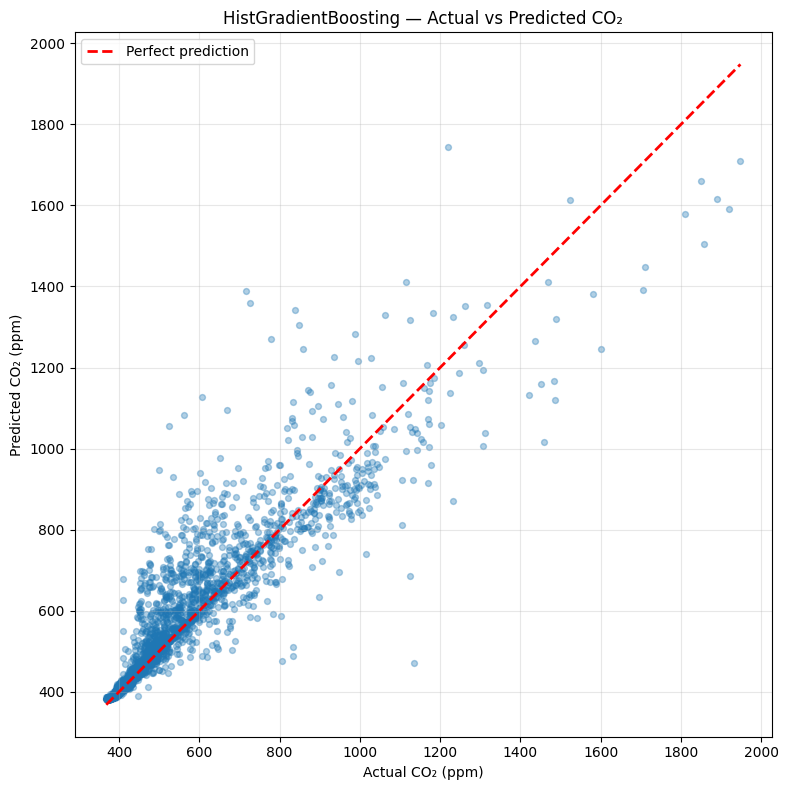

In [18]:
# ACTUAL VS PREDICTED — HISTGRADIENTBOOSTING

# This plot compares the predicted CO₂ concentration
# against the observed 30-minute-ahead CO₂ values.
# Perfect predictions lie on the diagonal reference line.


plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    hgb_pred,
    alpha=0.35,
    s=18
)

# Reference line representing perfect predictions
min_value = min(
    y_test.min(),
    hgb_pred.min()
)

max_value = max(
    y_test.max(),
    hgb_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual CO₂ (ppm)")
plt.ylabel("Predicted CO₂ (ppm)")
plt.title(
    "HistGradientBoosting — Actual vs Predicted CO₂"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "histgradientboosting_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

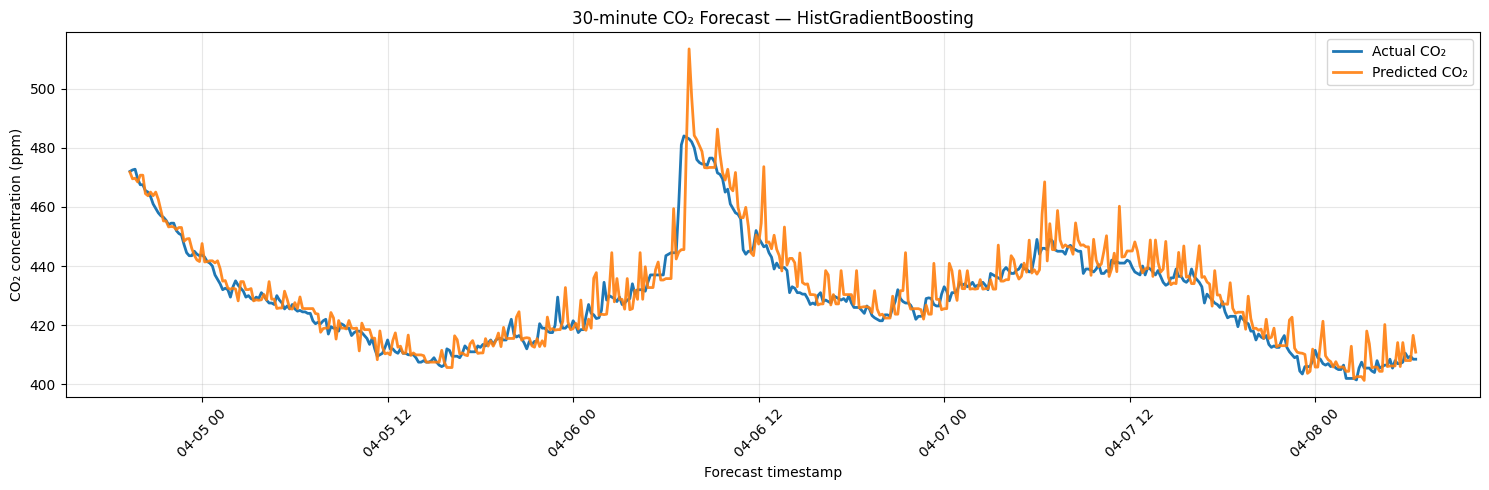

In [19]:
# TIME-SERIES COMPARISON — HISTGRADIENTBOOSTING

# The predictions are displayed using the timestamps
# corresponding to the forecasted CO₂ concentrations
# 30 minutes ahead.

# Number of samples displayed
n_samples = 500

# Forecast timestamps (30 minutes after the input observations)
forecast_timestamps = (
    df.loc[X_test.index, "target_ts_30min"]
    .reset_index(drop=True)
)

plt.figure(figsize=(15, 5))

plt.plot(
    forecast_timestamps.iloc[:n_samples],
    y_test.reset_index(drop=True).iloc[:n_samples],
    label="Actual CO₂",
    linewidth=2
)

plt.plot(
    forecast_timestamps.iloc[:n_samples],
    hgb_pred[:n_samples],
    label="Predicted CO₂",
    linewidth=2,
    alpha=0.90
)

plt.title(
    "30-minute CO₂ Forecast — HistGradientBoosting"
)

plt.xlabel("Forecast timestamp")
plt.ylabel("CO₂ concentration (ppm)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "histgradientboosting_co2_forecast_timeseries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

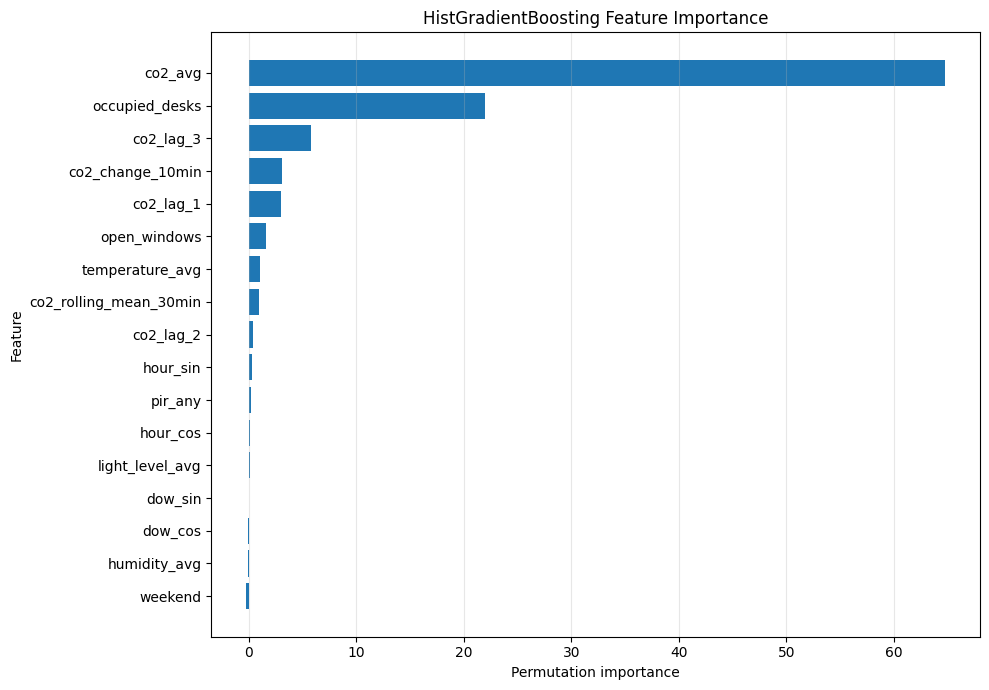

,Feature,Importance
0,co2_avg,64.766790
1,occupied_desks,21.988981
2,co2_lag_3,5.778663
3,co2_change_10min,3.117040
4,co2_lag_1,3.050371
5,open_windows,1.605793
6,temperature_avg,1.013164
7,co2_rolling_mean_30min,0.999381
8,co2_lag_2,0.432183
9,hour_sin,0.295997


In [20]:
# HISTGRADIENTBOOSTING FEATURE IMPORTANCE
# (Permutation Importance)

# ----------------------------------------------------------
# Estimate feature importance using permutation importance.
#
# Each feature is randomly shuffled while the remaining
# features are kept unchanged. The resulting increase in
# prediction error indicates how much the model relies on
# that feature.
#
# This approach is model-agnostic and generally provides
# a more reliable estimate of feature importance than
# impurity-based importance.
# ----------------------------------------------------------

perm = permutation_importance(
    hgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

# Sort for visualization
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Permutation importance")
plt.ylabel("Feature")

plt.title(
    "HistGradientBoosting Feature Importance"
)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "histgradientboosting_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Sort in descending order for reporting
feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance)

feature_importance.to_csv(
    "histgradientboosting_feature_importance.csv",
    index=False
)

## 3. Cross-Room Validation

The trained HistGradientBoosting model is applied directly to Rooms 2.3 and 3.9 without retraining or parameter adjustment.

This experiment evaluates whether the forecasting relationships learned in Room 4.9 remain useful in different Smart Campus environments.

In [21]:
# CROSS-ROOM PREPROCESSING FUNCTION
# — HISTGRADIENTBOOSTING

def prepare_cross_room_data(df_room, room_name):
    """
    Prepare an external room dataset using exactly the same
    feature engineering pipeline applied to Room 4.9 during
    model development.
    """

    # Work on a copy to avoid modifying the original dataframe.
    df_room = df_room.copy()

    # ------------------------------------------------------
    # 1. Timestamp preparation
    # ------------------------------------------------------

    df_room["ts"] = pd.to_datetime(df_room["ts"])

    df_room = (
        df_room
        .sort_values("ts")
        .reset_index(drop=True)
    )

    # ------------------------------------------------------
    # 2. Harmonize sensor column names
    # ------------------------------------------------------

    df_room = df_room.rename(columns={
        "co2": "co2_avg",
        "temperature": "temperature_avg",
        "humidity": "humidity_avg",
        "light_level": "light_level_avg",
        "pir": "pir_any",
        "open_windows_all": "open_windows"
    })

    # ------------------------------------------------------
    # 3. Create occupancy feature
    # ------------------------------------------------------
    # Room 2.3 uses its available people-count estimate.
    #
    # Room 3.9 uses the corrected occupancy produced in
    # Scenario 1, linking the output of the occupancy
    # estimation scenario with the CO₂ forecasting scenario.

    if room_name == "2.3":

        df_room["occupied_desks"] = (
            df_room["people_count_all"]
        )

    elif room_name == "3.9":

        if "corrected_occupancy" not in df_room.columns:
            raise ValueError(
                "Room 3.9 requires the 'corrected_occupancy' "
                "column from Scenario 1."
            )

        df_room["occupied_desks"] = (
            df_room["corrected_occupancy"]
        )

    else:

        raise ValueError(
            "Supported rooms are '2.3' and '3.9'."
        )

    # ------------------------------------------------------
    # 4. Prediction target
    # ------------------------------------------------------

    df_room["co2_future_30min"] = (
        df_room["co2_avg"].shift(-3)
    )

    df_room["target_ts_30min"] = (
        df_room["ts"].shift(-3)
    )

    # ------------------------------------------------------
    # 5. Time features
    # ------------------------------------------------------

    df_room["hour"] = df_room["ts"].dt.hour

    df_room["day_of_week"] = (
        df_room["ts"].dt.dayofweek
    )

    df_room["weekend"] = (
        df_room["day_of_week"] >= 5
    ).astype(int)

    df_room["hour_sin"] = np.sin(
        2 * np.pi * df_room["hour"] / 24
    )

    df_room["hour_cos"] = np.cos(
        2 * np.pi * df_room["hour"] / 24
    )

    df_room["dow_sin"] = np.sin(
        2 * np.pi * df_room["day_of_week"] / 7
    )

    df_room["dow_cos"] = np.cos(
        2 * np.pi * df_room["day_of_week"] / 7
    )

    # ------------------------------------------------------
    # 6. Historical CO₂ features
    # ------------------------------------------------------

    df_room["co2_lag_1"] = (
        df_room["co2_avg"].shift(1)
    )

    df_room["co2_lag_2"] = (
        df_room["co2_avg"].shift(2)
    )

    df_room["co2_lag_3"] = (
        df_room["co2_avg"].shift(3)
    )

    df_room["co2_change_10min"] = (
        df_room["co2_avg"]
        - df_room["co2_lag_1"]
    )

    df_room["co2_rolling_mean_30min"] = (
        df_room["co2_avg"]
        .shift(1)
        .rolling(
            window=3,
            min_periods=1
        )
        .mean()
    )

    # ------------------------------------------------------
    # 7. Select exactly the same feature set
    # ------------------------------------------------------

    cross_room_features = FEATURES.copy()

    required_columns = (
        cross_room_features
        + [
            "co2_future_30min",
            "target_ts_30min"
        ]
    )

    df_room = (
        df_room
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=required_columns)
        .copy()
    )

    # ------------------------------------------------------
    # 8. Keep only exact 30-minute targets
    # ------------------------------------------------------

    exact_30min_mask = (
        (
            df_room["target_ts_30min"]
            - df_room["ts"]
        )
        == pd.Timedelta(minutes=30)
    )

    df_room = (
        df_room.loc[exact_30min_mask]
        .copy()
    )

    X_room = (
        df_room[cross_room_features]
        .copy()
    )

    y_room = (
        df_room["co2_future_30min"]
        .copy()
    )

    timestamps = (
        df_room["ts"]
        .copy()
    )

    # ------------------------------------------------------
    # Final safety checks
    # ------------------------------------------------------

    assert (
        (
            df_room["target_ts_30min"]
            - df_room["ts"]
        )
        == pd.Timedelta(minutes=30)
    ).all()

    assert list(X_room.columns) == FEATURES

    print(f"Room {room_name}")
    print(f"Samples: {len(df_room):,}")

    print(
        f"Period: {timestamps.min()} → "
        f"{timestamps.max()}"
    )

    print(
        f"Number of model features: "
        f"{len(cross_room_features)}"
    )

    print(
        "✓ All prediction targets are exactly "
        "30 minutes ahead."
    )

    if room_name == "3.9":
        print(
            "✓ Corrected occupancy from Scenario 1 "
            "is used."
        )

    return (
        df_room,
        X_room,
        y_room,
        timestamps
    )

In [22]:
# LOAD CROSS-ROOM DATASETS

# Load external room datasets.
room_23_raw = pd.read_csv(
    "room_2_3_final.csv"
)

room_39_raw = pd.read_csv(
    "room_3_9_final.csv"
)

# Load the corrected occupancy estimate produced
# for Room 3.9 in Scenario 1.
room_39_corrected = pd.read_csv(
    "room_3_9_corrected_occupancy.csv"
)

# ----------------------------------------------------------
# Prepare timestamps before merging
# ----------------------------------------------------------

room_39_raw["ts"] = pd.to_datetime(
    room_39_raw["ts"]
)

room_39_corrected["ts"] = pd.to_datetime(
    room_39_corrected["ts"]
)

# ----------------------------------------------------------
# Merge corrected occupancy into Room 3.9 dataset
# ----------------------------------------------------------
# Only the corrected occupancy column is imported from
# Scenario 1 to avoid duplicating unrelated variables.

room_39_raw = room_39_raw.merge(
    room_39_corrected[
        [
            "ts",
            "corrected_occupancy"
        ]
    ],
    on="ts",
    how="left",
    validate="one_to_one"
)

# Safety check
assert "corrected_occupancy" in room_39_raw.columns

print(
    "Room 3.9 corrected occupancy matched rows:",
    room_39_raw["corrected_occupancy"]
    .notna()
    .sum()
)

print(
    "Room 3.9 missing corrected occupancy rows:",
    room_39_raw["corrected_occupancy"]
    .isna()
    .sum()
)

# ----------------------------------------------------------
# Prepare Room 2.3
# ----------------------------------------------------------

room_23, X_room_23, y_room_23, ts_room_23 = (
    prepare_cross_room_data(
        room_23_raw,
        room_name="2.3"
    )
)

print()

# ----------------------------------------------------------
# Prepare Room 3.9
# ----------------------------------------------------------

room_39, X_room_39, y_room_39, ts_room_39 = (
    prepare_cross_room_data(
        room_39_raw,
        room_name="3.9"
    )
)

Room 3.9 corrected occupancy matched rows: 38304
Room 3.9 missing corrected occupancy rows: 3
Room 2.3
Samples: 38,639
Period: 2025-09-01 15:10:00 → 2026-05-27 22:50:00
Number of model features: 17
✓ All prediction targets are exactly 30 minutes ahead.

Room 3.9
Samples: 36,916
Period: 2025-09-01 00:10:00 → 2026-05-28 16:20:00
Number of model features: 17
✓ All prediction targets are exactly 30 minutes ahead.
✓ Corrected occupancy from Scenario 1 is used.


In [23]:
# CROSS-ROOM PREDICTION AND EVALUATION

# ----------------------------------------------------------
# Cross-room predictions
# ----------------------------------------------------------
# The HistGradientBoosting model was trained exclusively
# using data from Room 4.9.
#
# The model is applied directly to Rooms 2.3 and 3.9
# without retraining, fine-tuning or parameter adjustment.
# This evaluates the model's ability to generalize to
# previously unseen rooms.

pred_room_23 = hgb.predict(
    X_room_23
)

pred_room_39 = hgb.predict(
    X_room_39
)

# Safety checks
assert len(pred_room_23) == len(y_room_23)
assert len(pred_room_39) == len(y_room_39)

# ----------------------------------------------------------
# Room 2.3 evaluation
# ----------------------------------------------------------

room_23_mae = mean_absolute_error(
    y_room_23,
    pred_room_23
)

room_23_rmse = np.sqrt(
    mean_squared_error(
        y_room_23,
        pred_room_23
    )
)

room_23_r2 = r2_score(
    y_room_23,
    pred_room_23
)

# ----------------------------------------------------------
# Room 3.9 evaluation
# ----------------------------------------------------------

room_39_mae = mean_absolute_error(
    y_room_39,
    pred_room_39
)

room_39_rmse = np.sqrt(
    mean_squared_error(
        y_room_39,
        pred_room_39
    )
)

room_39_r2 = r2_score(
    y_room_39,
    pred_room_39
)

# ----------------------------------------------------------
# Report cross-room performance
# ----------------------------------------------------------

print("Cross-Room Validation Results")
print("=" * 45)

print("\nRoom 2.3")
print(f"MAE  : {room_23_mae:.3f}")
print(f"RMSE : {room_23_rmse:.3f}")
print(f"R²   : {room_23_r2:.3f}")

print("\nRoom 3.9")
print(f"MAE  : {room_39_mae:.3f}")
print(f"RMSE : {room_39_rmse:.3f}")
print(f"R²   : {room_39_r2:.3f}")

print("\n✓ Cross-room evaluation completed successfully.")

Cross-Room Validation Results

Room 2.3
MAE  : 16.585
RMSE : 53.195
R²   : 0.865

Room 3.9
MAE  : 19.149
RMSE : 61.603
R²   : 0.846

✓ Cross-room evaluation completed successfully.


In [24]:
# CROSS-ROOM VALIDATION RESULTS

# Summarize the forecasting performance obtained on the
# original Room 4.9 test set and on the two external rooms.
#
# The external rooms are evaluated without retraining,
# providing an indication of the model's ability to
# generalize to unseen indoor environments.

cross_room_results = pd.DataFrame({
    "Room": [
        "Room 4.9 - Test Set",
        "Room 2.3 - Cross-Room Validation",
        "Room 3.9 - Cross-Room Validation"
    ],
    "MAE": [
        hgb_mae,
        room_23_mae,
        room_39_mae
    ],
    "RMSE": [
        hgb_rmse,
        room_23_rmse,
        room_39_rmse
    ],
    "R²": [
        hgb_r2,
        room_23_r2,
        room_39_r2
    ],
    "Samples": [
        len(y_test),
        len(y_room_23),
        len(y_room_39)
    ]
})

display(
    cross_room_results.round(3)
)

cross_room_results.to_csv(
    "histgradientboosting_cross_room_validation_results.csv",
    index=False
)

print(
    "\n✓ Cross-room validation results "
    "saved successfully."
)

,Room,MAE,RMSE,R²,Samples
0,Room 4.9 - Test Set,17.200,50.357,0.857,7737
1,Room 2.3 - Cross-Room Validation,16.585,53.195,0.865,38639
2,Room 3.9 - Cross-Room Validation,19.149,61.603,0.846,36916



✓ Cross-room validation results saved successfully.


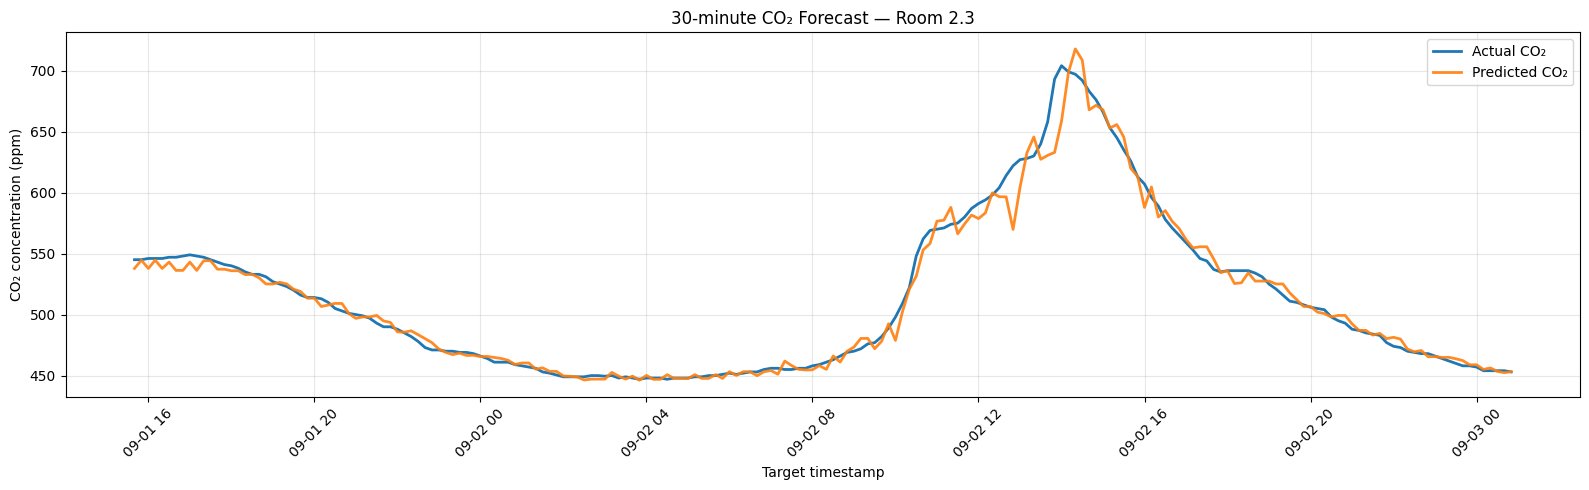

In [25]:
# 30-MINUTE CO₂ FORECAST — ROOM 2.3

# The predictions are displayed using the target timestamps,
# i.e., the timestamps corresponding to the future CO₂
# concentrations predicted 30 minutes in advance.


# Number of samples displayed
samples = 200

target_timestamps = (
    room_23["target_ts_30min"]
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 5))

plt.plot(
    target_timestamps.iloc[:samples],
    y_room_23.reset_index(drop=True).iloc[:samples],
    label="Actual CO₂",
    linewidth=2
)

plt.plot(
    target_timestamps.iloc[:samples],
    pred_room_23[:samples],
    label="Predicted CO₂",
    linewidth=2,
    alpha=0.90
)

plt.title(
    "30-minute CO₂ Forecast — Room 2.3"
)

plt.xlabel("Target timestamp")
plt.ylabel("CO₂ concentration (ppm)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "histgradientboosting_room23_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

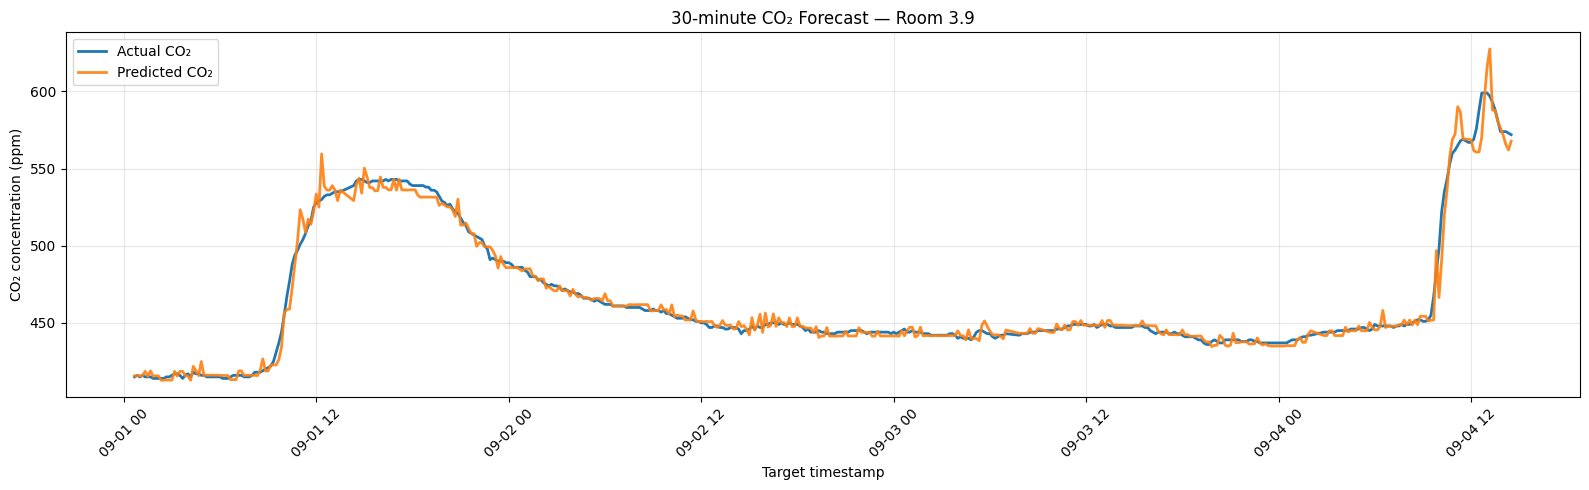

In [26]:
# 30-MINUTE CO₂ FORECAST — ROOM 3.9

# The predictions are displayed using the target timestamps,
# i.e., the timestamps corresponding to the future CO₂
# concentrations predicted 30 minutes in advance.


# Number of samples displayed
samples = 500

target_timestamps = (
    room_39["target_ts_30min"]
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 5))

plt.plot(
    target_timestamps.iloc[:samples],
    y_room_39.reset_index(drop=True).iloc[:samples],
    label="Actual CO₂",
    linewidth=2
)

plt.plot(
    target_timestamps.iloc[:samples],
    pred_room_39[:samples],
    label="Predicted CO₂",
    linewidth=2,
    alpha=0.90
)

plt.title(
    "30-minute CO₂ Forecast — Room 3.9"
)

plt.xlabel("Target timestamp")
plt.ylabel("CO₂ concentration (ppm)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "histgradientboosting_room39_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

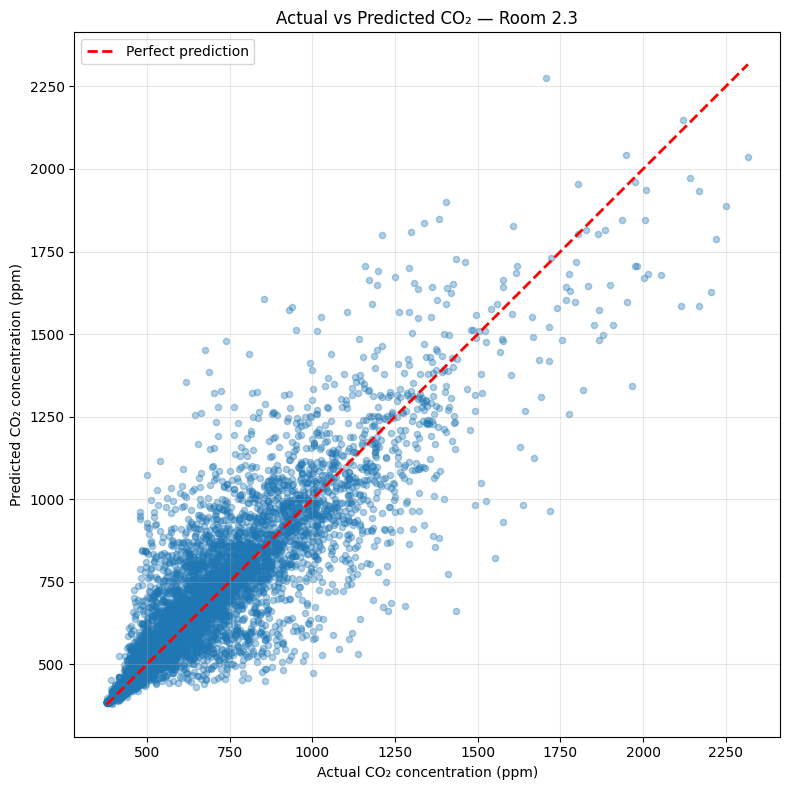

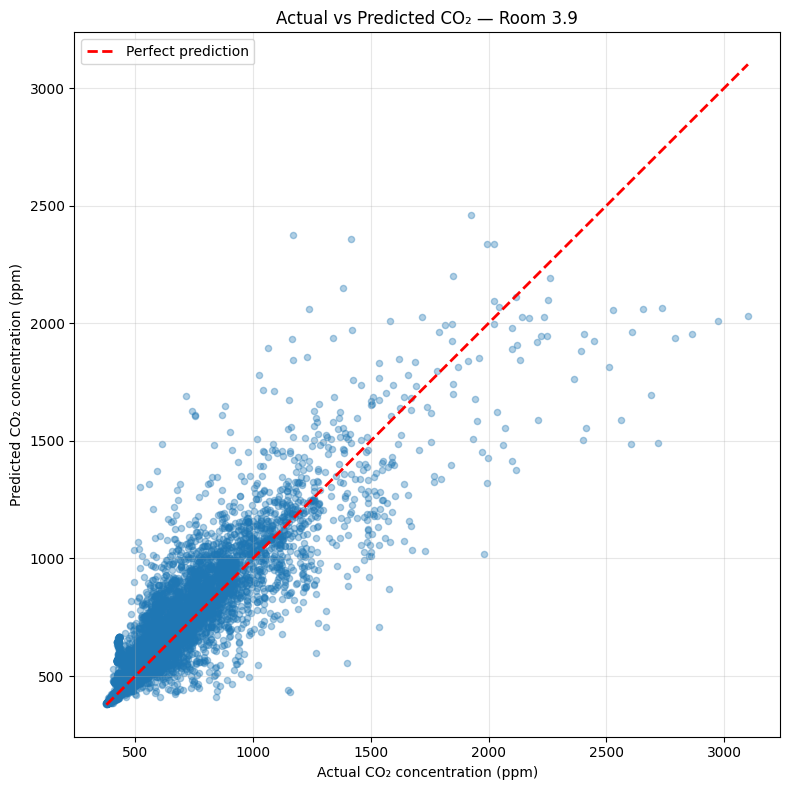

In [27]:
# ACTUAL VS PREDICTED — ROOMS 2.3 AND 3.9

def plot_actual_vs_predicted(
    y_actual,
    y_predicted,
    room_name,
    filename
):
    """
    Plot actual versus predicted CO₂ concentrations for
    cross-room validation.

    Points closer to the diagonal indicate smaller
    prediction errors.
    """

    plt.figure(figsize=(8, 8))

    plt.scatter(
        y_actual,
        y_predicted,
        alpha=0.35,
        s=20
    )

    # Determine common axis limits so that the
    # reference line spans the full plotting area.
    min_value = min(
        y_actual.min(),
        y_predicted.min()
    )

    max_value = max(
        y_actual.max(),
        y_predicted.max()
    )

    # Perfect prediction reference line
    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        "r--",
        linewidth=2,
        label="Perfect prediction"
    )

    plt.xlabel("Actual CO₂ concentration (ppm)")
    plt.ylabel("Predicted CO₂ concentration (ppm)")

    plt.title(
        f"Actual vs Predicted CO₂ — Room {room_name}"
    )

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ----------------------------------------------------------
# Room 2.3
# ----------------------------------------------------------

plot_actual_vs_predicted(
    y_room_23,
    pred_room_23,
    room_name="2.3",
    filename="histgradientboosting_room23_actual_vs_predicted.png"
)

# ----------------------------------------------------------
# Room 3.9
# ----------------------------------------------------------

plot_actual_vs_predicted(
    y_room_39,
    pred_room_39,
    room_name="3.9",
    filename="histgradientboosting_room39_actual_vs_predicted.png"
)

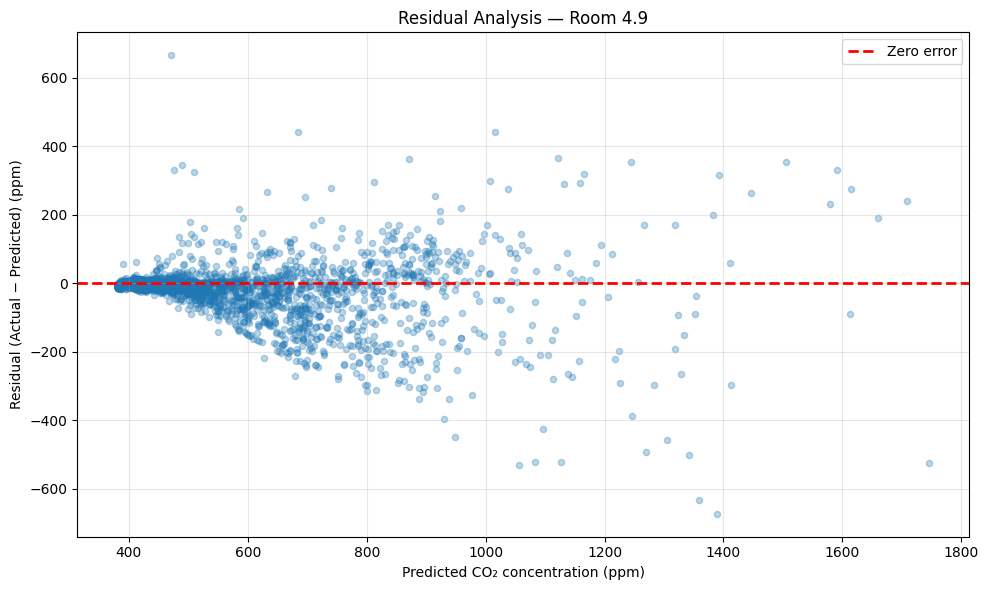

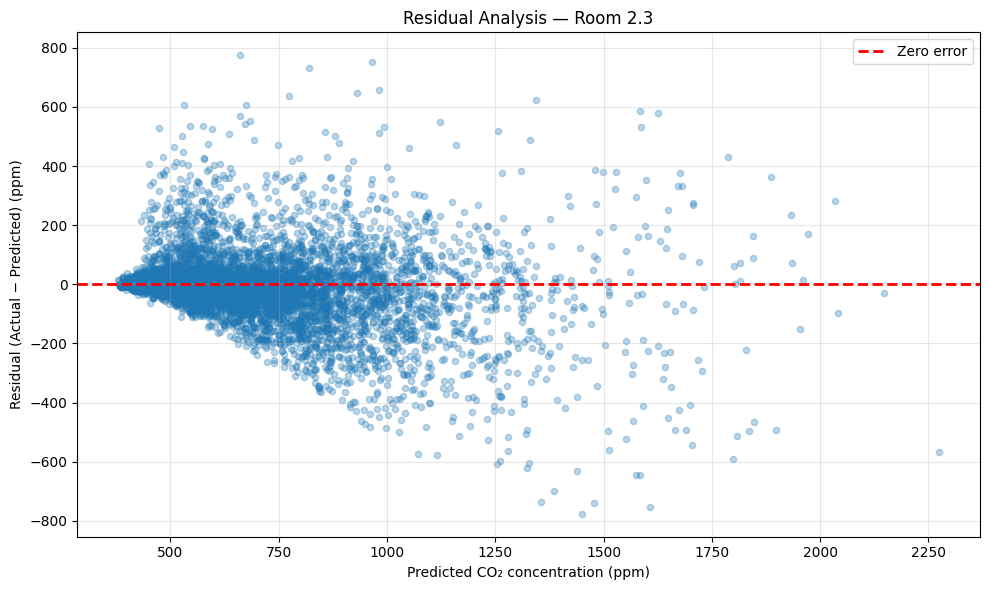

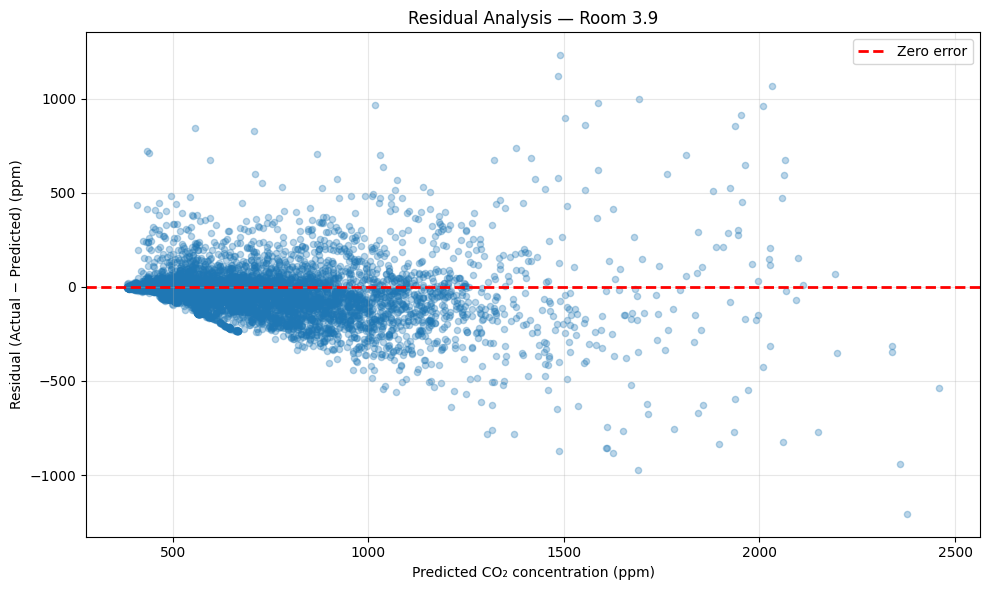

In [28]:
# RESIDUAL ANALYSIS

# ----------------------------------------------------------
# Residuals are computed as:
#
# Residual = Actual CO₂ − Predicted CO₂
#
# Positive residuals indicate underestimation,
# while negative residuals indicate overestimation.
# ----------------------------------------------------------

residuals_49 = (
    np.asarray(y_test)
    - np.asarray(hgb_pred)
)

residuals_23 = (
    np.asarray(y_room_23)
    - np.asarray(pred_room_23)
)

residuals_39 = (
    np.asarray(y_room_39)
    - np.asarray(pred_room_39)
)


def plot_residuals(
    y_predicted,
    residuals,
    room_name,
    filename
):
    """
    Plot prediction residuals against predicted CO₂ values.

    A residual distribution centered approximately around
    zero suggests limited systematic prediction bias.
    """

    plt.figure(figsize=(10, 6))

    plt.scatter(
        y_predicted,
        residuals,
        alpha=0.30,
        s=20
    )

    # Reference line corresponding to zero prediction error.
    plt.axhline(
        y=0,
        color="red",
        linestyle="--",
        linewidth=2,
        label="Zero error"
    )

    plt.xlabel("Predicted CO₂ concentration (ppm)")
    plt.ylabel("Residual (Actual − Predicted) (ppm)")

    plt.title(
        f"Residual Analysis — Room {room_name}"
    )

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ----------------------------------------------------------
# Room 4.9
# ----------------------------------------------------------

plot_residuals(
    hgb_pred,
    residuals_49,
    room_name="4.9",
    filename="histgradientboosting_room49_residual_plot.png"
)

# ----------------------------------------------------------
# Room 2.3
# ----------------------------------------------------------

plot_residuals(
    pred_room_23,
    residuals_23,
    room_name="2.3",
    filename="histgradientboosting_room23_residual_plot.png"
)

# ----------------------------------------------------------
# Room 3.9
# ----------------------------------------------------------

plot_residuals(
    pred_room_39,
    residuals_39,
    room_name="3.9",
    filename="histgradientboosting_room39_residual_plot.png"
)

In [29]:
# RESIDUAL SUMMARY

# Summarize the residual distribution for each room.
#
# The mean residual provides an indication of systematic bias,
# whereas the residual standard deviation reflects the spread
# of the prediction errors.

residual_summary = pd.DataFrame({
    "Room": [
        "Room 4.9",
        "Room 2.3",
        "Room 3.9"
    ],
    "Mean Residual": [
        residuals_49.mean(),
        residuals_23.mean(),
        residuals_39.mean()
    ],
    "Median Residual": [
        np.median(residuals_49),
        np.median(residuals_23),
        np.median(residuals_39)
    ],
    "Residual Std": [
        residuals_49.std(),
        residuals_23.std(),
        residuals_39.std()
    ],
    "Min Residual": [
        residuals_49.min(),
        residuals_23.min(),
        residuals_39.min()
    ],
    "Max Residual": [
        residuals_49.max(),
        residuals_23.max(),
        residuals_39.max()
    ]
})

display(
    residual_summary.round(3)
)

residual_summary.to_csv(
    "histgradientboosting_residual_summary.csv",
    index=False
)

print("✓ Residual summary saved successfully.")

,Room,Mean Residual,Median Residual,Residual Std,Min Residual,Max Residual
0,Room 4.9,-8.105,-1.719,49.700,-672.794,664.972
1,Room 2.3,-2.619,-0.570,53.130,-776.288,774.888
2,Room 3.9,-6.917,-0.985,61.214,-1205.393,1229.985


✓ Residual summary saved successfully.


In [30]:
# EXPORT FINAL PREDICTIONS

# Export both the forecast origin timestamp and the target timestamp.
# This makes it explicit when each prediction was generated
# and which future CO₂ measurement it refers to.

# ----------------------------------------------------------
# Room 4.9
# ----------------------------------------------------------

predictions_room_49 = pd.DataFrame({
    "forecast_origin_ts": (
        df.loc[X_test.index, "ts"].values
    ),
    "target_ts": (
        df.loc[X_test.index, "target_ts_30min"].values
    ),
    "room": "4.9",
    "actual_co2_30min": np.asarray(y_test),
    "predicted_co2_30min": np.asarray(hgb_pred),
    "residual": residuals_49,
    "absolute_error": np.abs(residuals_49)
})

# ----------------------------------------------------------
# Room 2.3
# ----------------------------------------------------------

predictions_room_23 = pd.DataFrame({
    "forecast_origin_ts": room_23["ts"].values,
    "target_ts": room_23["target_ts_30min"].values,
    "room": "2.3",
    "actual_co2_30min": np.asarray(y_room_23),
    "predicted_co2_30min": np.asarray(pred_room_23),
    "residual": residuals_23,
    "absolute_error": np.abs(residuals_23)
})

# ----------------------------------------------------------
# Room 3.9
# ----------------------------------------------------------

predictions_room_39 = pd.DataFrame({
    "forecast_origin_ts": room_39["ts"].values,
    "target_ts": room_39["target_ts_30min"].values,
    "room": "3.9",
    "actual_co2_30min": np.asarray(y_room_39),
    "predicted_co2_30min": np.asarray(pred_room_39),
    "residual": residuals_39,
    "absolute_error": np.abs(residuals_39)
})

# ----------------------------------------------------------
# Combine predictions from all rooms
# ----------------------------------------------------------

all_predictions = pd.concat(
    [
        predictions_room_49,
        predictions_room_23,
        predictions_room_39
    ],
    ignore_index=True
)

# ----------------------------------------------------------
# Safety checks
# ----------------------------------------------------------

assert len(predictions_room_49) == len(y_test)
assert len(predictions_room_23) == len(y_room_23)
assert len(predictions_room_39) == len(y_room_39)

# Verify that every prediction refers exactly
# to a timestamp 30 minutes in the future.

expected_horizon = pd.Timedelta(minutes=30)

assert (
    predictions_room_49["target_ts"]
    - predictions_room_49["forecast_origin_ts"]
    == expected_horizon
).all()

assert (
    predictions_room_23["target_ts"]
    - predictions_room_23["forecast_origin_ts"]
    == expected_horizon
).all()

assert (
    predictions_room_39["target_ts"]
    - predictions_room_39["forecast_origin_ts"]
    == expected_horizon
).all()

print("✓ Prediction export checks passed.")

# ----------------------------------------------------------
# Save final prediction file
# ----------------------------------------------------------

all_predictions.to_csv(
    "histgradientboosting_all_rooms_predictions.csv",
    index=False
)

display(all_predictions.head())

print(
    f"\nSaved {len(all_predictions):,} predictions "
    "to histgradientboosting_all_rooms_predictions.csv"
)

print("✓ Final prediction export completed successfully.")

✓ Prediction export checks passed.


,forecast_origin_ts,target_ts,room,actual_co2_30min,predicted_co2_30min,residual,absolute_error
0,2026-04-04 18:50:00,2026-04-04 19:20:00,4.9,472.00,471.745206,0.254794,0.254794
1,2026-04-04 19:00:00,2026-04-04 19:30:00,4.9,472.50,469.492332,3.007668,3.007668
2,2026-04-04 19:10:00,2026-04-04 19:40:00,4.9,472.75,469.696785,3.053215,3.053215
3,2026-04-04 19:20:00,2026-04-04 19:50:00,4.9,469.50,468.430638,1.069362,1.069362
4,2026-04-04 19:30:00,2026-04-04 20:00:00,4.9,467.50,470.723351,-3.223351,3.223351



Saved 83,292 predictions to histgradientboosting_all_rooms_predictions.csv
✓ Final prediction export completed successfully.


Displayed period: 2026-04-04 19:20:00 → 2026-04-11 19:10:00
Displayed observations: 1,008


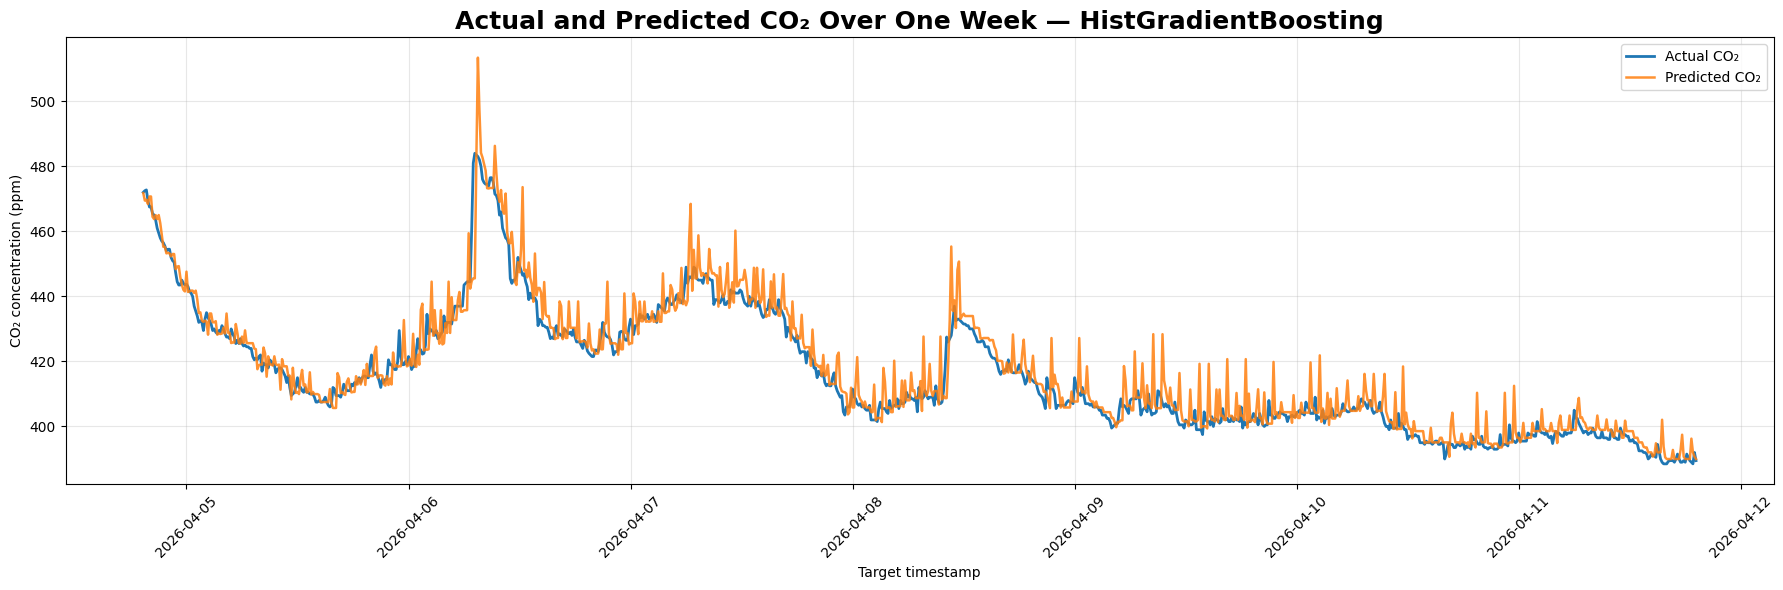

In [31]:
# ONE-WEEK ACTUAL VS PREDICTED CO₂ — HISTGRADIENTBOOSTING

# Display a continuous seven-day period from the test set.
# The x-axis uses the target timestamps, i.e., the actual
# timestamps of the CO₂ concentrations predicted 30 minutes ahead.

# ----------------------------------------------------------
# Build plotting dataframe using forecast target timestamps
# ----------------------------------------------------------

week_df = pd.DataFrame({
    "target_ts": (
        df.loc[X_test.index, "target_ts_30min"]
        .reset_index(drop=True)
    ),
    "actual_co2": (
        y_test
        .reset_index(drop=True)
    ),
    "predicted_co2": hgb_pred
})

# ----------------------------------------------------------
# Select exactly one calendar week
# ----------------------------------------------------------

week_start = week_df["target_ts"].min()
week_end = week_start + pd.Timedelta(days=7)

week_plot = week_df[
    (week_df["target_ts"] >= week_start)
    &
    (week_df["target_ts"] < week_end)
].copy()

print(
    f"Displayed period: "
    f"{week_plot['target_ts'].min()} → "
    f"{week_plot['target_ts'].max()}"
)

print(
    f"Displayed observations: {len(week_plot):,}"
)

# ----------------------------------------------------------
# Plot actual and predicted CO₂
# ----------------------------------------------------------

plt.figure(figsize=(18, 6))

plt.plot(
    week_plot["target_ts"],
    week_plot["actual_co2"],
    label="Actual CO₂",
    linewidth=2
)

plt.plot(
    week_plot["target_ts"],
    week_plot["predicted_co2"],
    label="Predicted CO₂",
    linewidth=1.8,
    alpha=0.85
)

plt.title(
    "Actual and Predicted CO₂ Over One Week — HistGradientBoosting",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Target timestamp")
plt.ylabel("CO₂ concentration (ppm)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "Figure_AQ_Actual_vs_Predicted_One_Week_HistGradientBoosting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
# FINAL MODELING DATASET SUMMARY

# Report the final dataset used for model development
# after target creation, feature engineering and filtering.

print("Final modeling dataset period:")
print(
    df["ts"].min(),
    "→",
    df["ts"].max()
)

print("\nFinal modeling dataset samples:")
print(f"{len(df):,}")

Final modeling dataset period:
2025-09-01 21:10:00 → 2026-05-28 12:10:00

Final modeling dataset samples:
38,683


## Conclusions

The HistGradientBoosting model achieved the best overall predictive performance for 30-minute CO₂ forecasting in Room 4.9.

The model also maintained comparable predictive performance when applied without retraining to Rooms 2.3 and 3.9, providing evidence of transferability within the examined Smart Campus environment.

Overall, the forecasting pipeline provides a robust basis for short-term indoor air quality prediction and for the ventilation recommendation scenario that follows.

## 4. Scenario 2 Summary

HistGradientBoosting provided the strongest overall performance for 30-minute CO₂ forecasting in Room 4.9 and maintained comparable predictive performance when applied without retraining to Rooms 2.3 and 3.9.

The results indicate that current CO₂ concentration, recent CO₂ dynamics and occupancy information provide useful predictive information for short-term indoor air quality forecasting. The resulting forecasting model is subsequently used as an input to the ventilation recommendation scenario.

In [33]:
# SAVE TRAINED HISTGRADIENTBOOSTING MODEL

joblib.dump(
    hgb,
    "histgradientboosting_co2_forecasting_model.pkl"
)

print(
    "HistGradientBoosting model saved successfully."
)

HistGradientBoosting model saved successfully.
